# Загрузка библиотек

In [330]:
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import seaborn as sns
import joblib

# Загрузка датасетов

In [331]:
features = pd.read_csv("Features data set.csv")
stores = pd.read_csv("stores data-set.csv")
sales = pd.read_csv("sales data-set.csv")

In [332]:
print(sales.dtypes)
print(features.dtypes)
print(stores.dtypes)

Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object
Store             int64
Date             object
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object
Store     int64
Type     object
Size      int64
dtype: object


Дату из obj надо перевести в dt
Да и в целом по всем параметрам и привести их в норм. форматы

In [333]:
features["Store"]=features["Store"].astype("category")
features["Date"]=pd.to_datetime(features["Date"],dayfirst=True)
features["IsHoliday"]=features["IsHoliday"].map({True:1,False:0}).astype("category")
features["Week"]=features["Date"].dt.isocalendar().week
features["Year"]=features["Date"].dt.isocalendar().year
for i in range(1,6):
  if i==1:
    features["MarkDowns"]=features["MarkDown%s" % i]
  else:
    features["MarkDowns"]=features["MarkDowns"]+features["MarkDown%s" % i]
featsfloatcols=["Temperature","Fuel_Price","CPI", "Unemployment", "MarkDowns"]+["MarkDown%s" % i for i in range(1,6)]
features[featsfloatcols]=features[featsfloatcols].astype("float64")
features["Weight"]=features["IsHoliday"].map({1:5,0:1}).astype("int64")
stores["Store"]=stores["Store"].astype("category")
stores["Type"]=stores["Type"].astype("category")

sales["Store"]=sales["Store"].astype("category")
sales["Dept"]=sales["Dept"].astype("category")
sales["IsHoliday"]=sales["IsHoliday"].map({True:1,False:0}).astype("category")
sales["Date"]=pd.to_datetime(sales["Date"],dayfirst=True)

In [334]:
# итого:

print(sales.dtypes)
print(features.dtypes)
print(stores.dtypes)

Store                 category
Dept                  category
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday             category
dtype: object
Store                 category
Date            datetime64[ns]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday             category
Week                    UInt32
Year                    UInt32
MarkDowns              float64
Weight                   int64
dtype: object
Store    category
Type     category
Size        int64
dtype: object


In [335]:
# заготовка для Марселя для предсказаний
# используем на сл. этапе проекта

futuresales=sales[["Store","Dept"]].drop_duplicates()
futuresales["Weekly_Sales"]=np.nan
futuredates=features[features["Date"]>sales["Date"].max()][["Store","Date","IsHoliday"]]
futuresales=futuresales.merge(futuredates,on="Store", how="outer")
salesV2=pd.concat([sales,futuresales])

In [336]:
# объединяем датасеты

tmp = pd.merge(features, sales, on=['Store', 'Date'], how='inner', suffixes=('', '_sales'))
data = pd.merge(tmp, stores, on='Store', how='inner')
data = data.drop(columns=['IsHoliday_sales'])  # `features` contains more information than `sales`, so drop the `IsHoliday` column from `sales`
data['Date'] = pd.to_datetime(data['Date'], format='%d/%m/%Y')
data.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week,Year,MarkDowns,Weight,Dept,Weekly_Sales,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,2010,NaN,1,1,24924.50,A,151315
1,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,2010,NaN,1,2,50605.27,A,151315
2,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,2010,NaN,1,3,13740.12,A,151315
3,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,2010,NaN,1,4,39954.04,A,151315
4,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,2010,NaN,1,5,32229.38,A,151315


In [337]:
# размерность

print(sales.shape, features.shape, stores.shape)

(421570, 5) (8190, 16) (45, 3)


In [338]:
# смотрим что получилось в конечном датасете

data.describe()

,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Week,Year,MarkDowns,Weight,Weekly_Sales,Size
count,421570,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.0,421570.0,97056.000000,421570.000000,421570.000000,421570.000000
mean,2011-06-18 08:30:31.963375360,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,25.826762,2010.968591,23688.175817,1.281434,15981.258123,136727.915739
min,2010-02-05 00:00:00,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,1.0,2010.0,567.350000,1.000000,-4988.940000,34875.000000
25%,2010-10-08 00:00:00,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,14.0,2010.0,9944.170000,1.000000,2079.650000,93638.000000
50%,2011-06-17 00:00:00,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,26.0,2011.0,16718.320000,1.000000,7612.030000,140167.000000
75%,2012-02-24 00:00:00,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,38.0,2012.0,28378.110000,1.000000,20205.852500,202505.000000
max,2012-10-26 00:00:00,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,52.0,2012.0,160510.610000,5.000000,693099.360000,219622.000000
std,NaN,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,14.151887,0.796876,21717.452137,1.023002,22711.183519,60980.583328


In [339]:
data = data.sort_values(by='Date')

In [340]:
sales_across_time = data.groupby(by=['Date'], as_index=False)['Weekly_Sales'].sum()

<function matplotlib.pyplot.show(close=None, block=None)>

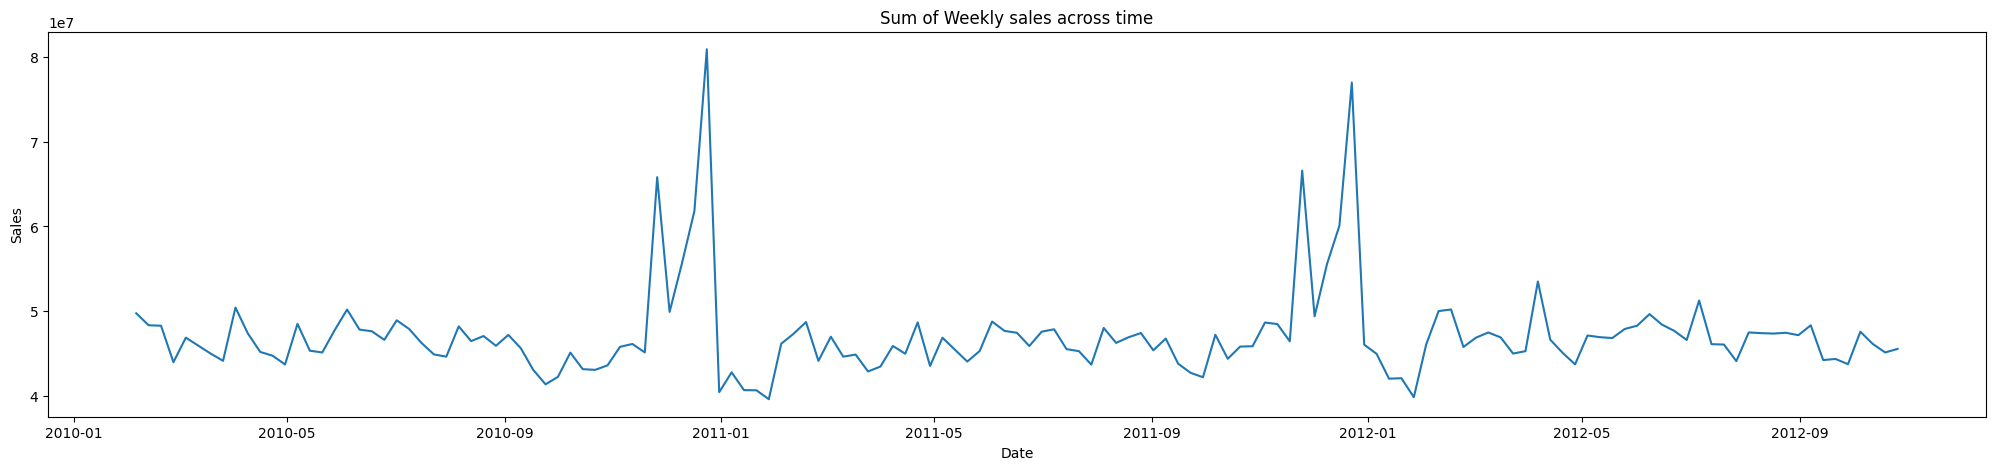

In [341]:
sales_across_time = data.groupby(by = ['Date'], as_index = False)['Weekly_Sales'].sum()

plt.figure(figsize = (25,5))
plt.plot(sales_across_time.Date, sales_across_time.Weekly_Sales)
plt.title("Sum of Weekly sales across time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show

In [342]:
print(data.shape)

(421570, 20)


In [343]:
tmp = data[['Date']].drop_duplicates()
max_date = tmp.max().iloc[0]
min_date = tmp.min().iloc[0]
cnt = (max_date - min_date).days // 7 + 1

print('max date: %s, min date: %s\n'
      'number of weeks between max date and min date: %d\n'
      'number of unique dates in data: %d\n'
      'is the dates all Friday: %s' %
      (max_date.strftime('%Y-%m-%d'), min_date.strftime('%Y-%m-%d'), cnt, tmp.shape[0], (tmp['Date'].dt.day_name() == 'Friday').all()))

max date: 2012-10-26, min date: 2010-02-05
number of weeks between max date and min date: 143
number of unique dates in data: 143
is the dates all Friday: True


In [344]:
bins = [0, 75000, 175000, 225000]
labels = ['div_3', 'div_2', 'div_1']

stores_2 = stores.copy()
stores_2['Division'] = pd.cut(
    stores_2['Size'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)
stores_2

,Store,Type,Size,Division
0,1,A,151315,div_2
1,2,A,202307,div_1
2,3,B,37392,div_3
3,4,A,205863,div_1
4,5,B,34875,div_3
5,6,A,202505,div_1
6,7,B,70713,div_3
7,8,A,155078,div_2
8,9,B,125833,div_2
9,10,B,126512,div_2


In [345]:
bins = [0, 75000, 175000, 225000]
labels = ['div_3', 'div_2', 'div_1']

result_2 = data.copy()
result_2['Division'] = pd.cut(
    result_2['Size'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)
result_2

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,...,IsHoliday,Week,Year,MarkDowns,Weight,Dept,Weekly_Sales,Type,Size,Division
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,...,0,5,2010,NaN,1,1,24924.50,A,151315,div_2
330761,35,2010-02-05,27.19,2.784,NaN,NaN,NaN,NaN,NaN,135.352461,...,0,5,2010,NaN,1,3,14612.19,B,103681,div_2
330762,35,2010-02-05,27.19,2.784,NaN,NaN,NaN,NaN,NaN,135.352461,...,0,5,2010,NaN,1,4,26323.15,B,103681,div_2
330763,35,2010-02-05,27.19,2.784,NaN,NaN,NaN,NaN,NaN,135.352461,...,0,5,2010,NaN,1,5,36414.63,B,103681,div_2
330764,35,2010-02-05,27.19,2.784,NaN,NaN,NaN,NaN,NaN,135.352461,...,0,5,2010,NaN,1,6,11437.81,B,103681,div_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128051,13,2012-10-26,46.97,3.755,10192.49,364.57,150.0,1714.15,5563.92,131.193097,...,0,43,2012,17985.13,1,49,7770.71,A,219622,div_1
128052,13,2012-10-26,46.97,3.755,10192.49,364.57,150.0,1714.15,5563.92,131.193097,...,0,43,2012,17985.13,1,50,1486.00,A,219622,div_1
128053,13,2012-10-26,46.97,3.755,10192.49,364.57,150.0,1714.15,5563.92,131.193097,...,0,43,2012,17985.13,1,52,4738.93,A,219622,div_1
390991,41,2012-10-26,41.80,3.686,4864.30,101.34,250.6,47.24,1524.43,199.219532,...,0,43,2012,6787.91,1,4,32699.78,A,196321,div_1


Смотрим распределение NaN значений в Markdown колонках по отношению ко времени

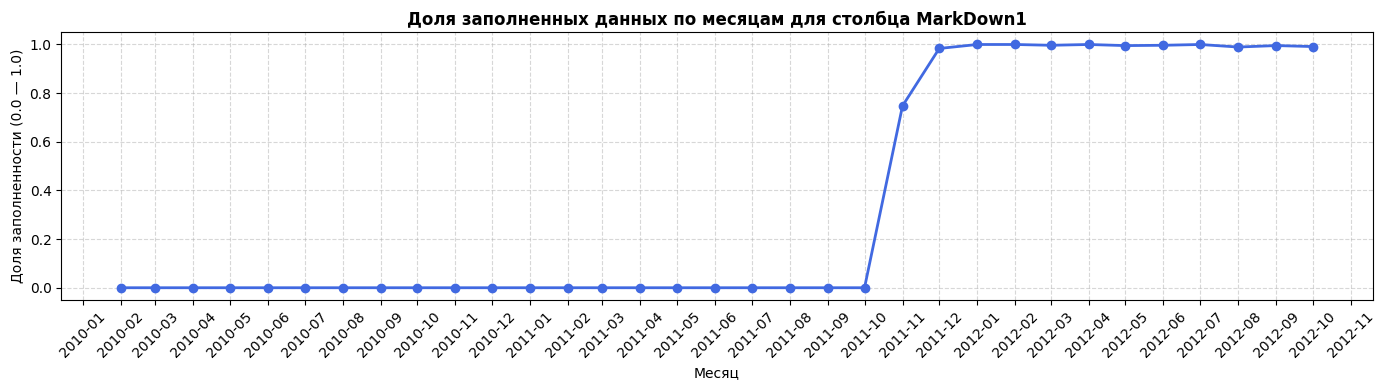

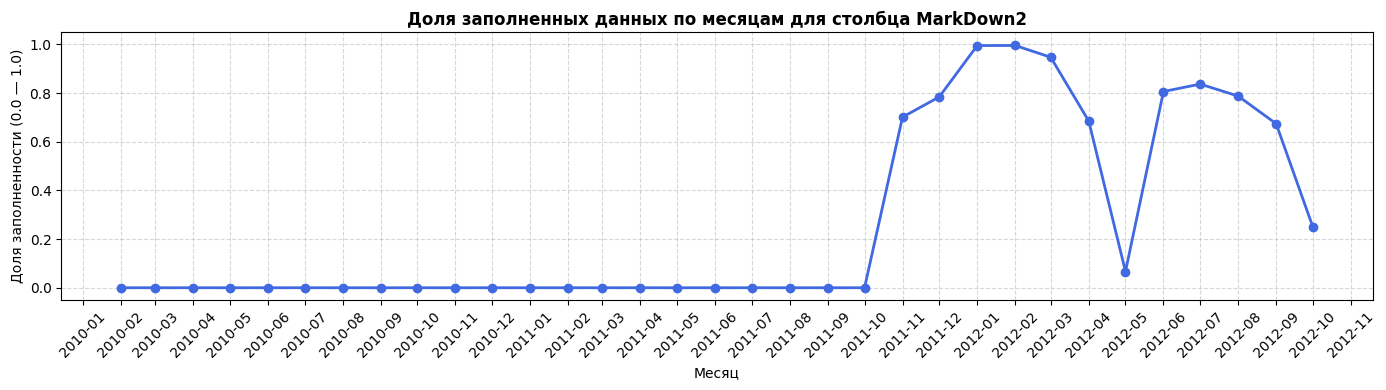

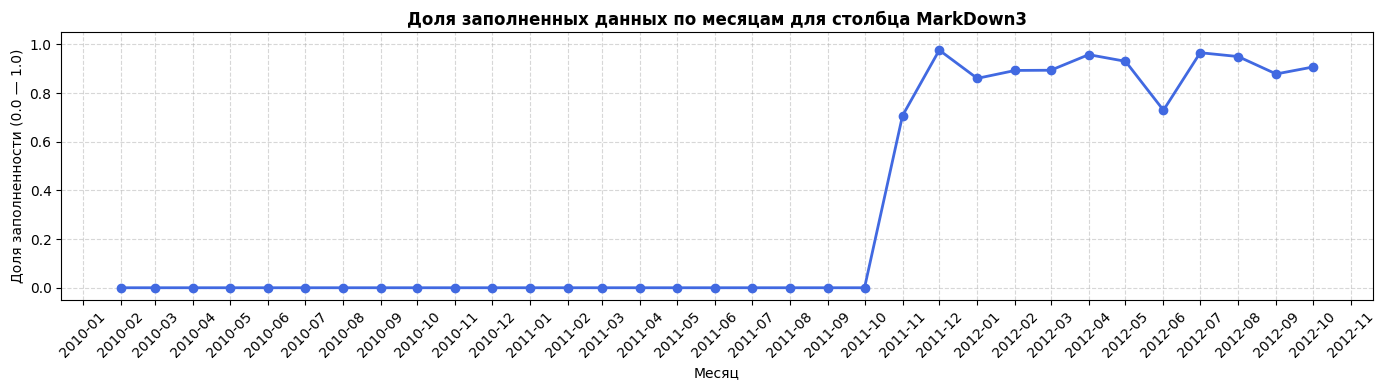

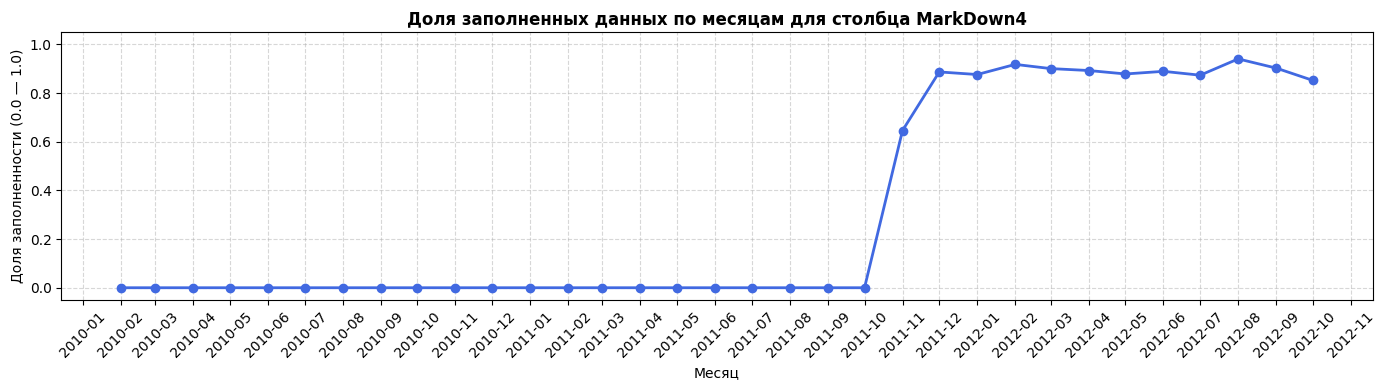

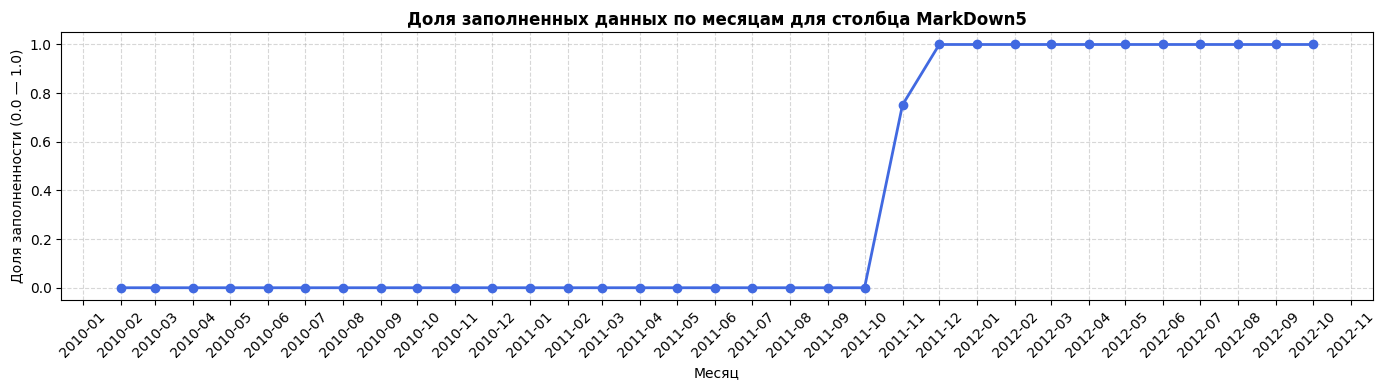

In [346]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
result_2['Month'] = result_2['Date'].dt.to_period('M').dt.to_timestamp()

for col in markdown_cols:
    plt.figure(figsize=(14, 4))

    monthly_agg = result_2.groupby('Month')[col].agg(
        Total='size',
        Filled=lambda x: x.notna().sum()
    ).reset_index()

    monthly_agg['Ratio'] = monthly_agg['Filled'] / monthly_agg['Total']

    plt.plot(monthly_agg['Month'], monthly_agg['Ratio'], marker='o', linestyle='-', color='royalblue', linewidth=2)

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)

    plt.title(f'Доля заполненных данных по месяцам для столбца {col}', fontsize=12, fontweight='bold')
    plt.xlabel('Месяц', fontsize=10)
    plt.ylabel('Доля заполненности (0.0 — 1.0)', fontsize=10)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Гипотеза 2: Синергетический эффект скидок в праздничные недели


Оптимальное распределение уценок/скидок именно в праздничные недели приводит к синергетическому эффекту  максимизации недельной выручки

In [347]:
result_2['Date'] = pd.to_datetime(result_2['Date'], errors='coerce')

In [348]:
from scipy import stats

Формируем выборки по признаку праздника - isholiday
и проверяем гипотезу на основании 4 сценариев:

обычная неделя скидки/без скидок, праздничная неделя скидки/без скидок


In [349]:
# переприводим к типам, проверяем пропуски
result_2['Date'] = pd.to_datetime(result_2['Date'], errors='coerce')

if str(result_2['IsHoliday'].dtype) == 'category':
    result_2['IsHoliday_bool'] = result_2['IsHoliday'].astype(str).str.lower().isin(['true', '1', 'yes'])
else:
    result_2['IsHoliday_bool'] = result_2['IsHoliday'].astype(bool)

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
for col in markdown_cols:
    if col in result_2.columns:
        result_2[col] = pd.to_numeric(result_2[col], errors='coerce').fillna(0)

result_2['Total_MarkDown'] = result_2[[c for c in markdown_cols if c in result_2.columns]].sum(axis=1)
result_2['Has_Markdown'] = result_2['Total_MarkDown'] > 0

In [350]:
# формируем подвыборки


sales_holiday_promo = result_2[(result_2['IsHoliday_bool'] == True) & (result_2['Has_Markdown'] == True)]['Weekly_Sales'].dropna()
sales_holiday_nopromo = result_2[(result_2['IsHoliday_bool'] == True) & (result_2['Has_Markdown'] == False)]['Weekly_Sales'].dropna()

sales_normal_promo = result_2[(result_2['IsHoliday_bool'] == False) & (result_2['Has_Markdown'] == True)]['Weekly_Sales'].dropna()
sales_normal_nopromo = result_2[(result_2['IsHoliday_bool'] == False) & (result_2['Has_Markdown'] == False)]['Weekly_Sales'].dropna()

print(f"размер выборки праздник + скидка {len(sales_holiday_promo):,}")
print(f"размер выборки праздник без скидки {len(sales_holiday_nopromo):,}")
print(f"размер выборки обычная неделя + скидка {len(sales_normal_promo):,}")
print(f"размер выборки обычная неделя без скидки {len(sales_normal_nopromo):,}\n")

print(f"ср. продажи праздник + кидка {sales_holiday_promo.mean():,.2f}")
print(f"ср. продажи праздник без скидки {sales_holiday_nopromo.mean():,.2f}")
print(f"ср. продажи обычная неделя + скидка {sales_normal_promo.mean():,.2f}")
print(f"ср. продажи обычная неделя без скидки {sales_normal_nopromo.mean():,.2f}\n")

размер выборки праздник + скидка 11,991
размер выборки праздник без скидки 17,670
размер выборки обычная неделя + скидка 139,441
размер выборки обычная неделя без скидки 252,468

ср. продажи праздник + кидка 17,594.49
ср. продажи праздник без скидки 16,656.71
ср. продажи обычная неделя + скидка 16,055.12
ср. продажи обычная неделя без скидки 15,816.57



пупупуууу... группы имбаласны

проверим


In [351]:
groups = {
    'праздник + скидка': sales_holiday_promo,
    'праздник без скидки': sales_holiday_nopromo,
    'обычная неделя + скидка': sales_normal_promo,
    'обычная неделя без скидки': sales_normal_nopromo
}

for name, group in groups.items():
    print(f"{name:.<40} {len(group):>6,}")

sizes = [len(g) for g in groups.values()]
ratio = max(sizes) / min(sizes)
print(f"соотношение {ratio:.2f}x")

if ratio > 10:
    print(">10x")
elif ratio > 3:
    print("3-10x")
else:
    print("<3x")

праздник + скидка....................... 11,991
праздник без скидки..................... 17,670
обычная неделя + скидка................. 139,441
обычная неделя без скидки............... 252,468
соотношение 21.05x
>10x


жесть дисбаланс....


In [352]:
# дисперсионный анализ для всех четырех групп
# велч АНОВА? более устойчив к разным размерам и дисперсиям
f_stat, p_val = stats.f_oneway(
    sales_holiday_promo,
    sales_holiday_nopromo,
    sales_normal_promo,
    sales_normal_nopromo
)

print(f"f-статистика  {f_stat:.4f}")
print(f"p-value {p_val:.4e}")

f-статистика  30.3004
p-value 1.4095e-19


In [353]:
holiday_pct = (len(sales_holiday_promo) + len(sales_holiday_nopromo)) / (len(sales_holiday_promo) + len(sales_holiday_nopromo) + len(sales_normal_promo) + len(sales_normal_nopromo)) * 100
print(f"а какая вообще у нас доля праздников?: {holiday_pct:.1f}%")

а какая вообще у нас доля праздников?: 7.0%


In [354]:
# посмотрим как дела по типам магазинов

for store_type in result_2['Division'].unique():
    store_data = result_2[result_2['Division'] == store_type]

    hp = store_data[(store_data['IsHoliday_bool'] == True) & (store_data['Has_Markdown'] == True)]['Weekly_Sales'].dropna()
    hnp = store_data[(store_data['IsHoliday_bool'] == True) & (store_data['Has_Markdown'] == False)]['Weekly_Sales'].dropna()

    if len(hp) > 30 and len(hnp) > 30:
        lift = ((hp.mean() / hnp.mean()) - 1) * 100
        print(f"\nТип {store_type}: прирост {lift:+.1f}% (n={len(hp):,} vs {len(hnp):,})")
    else:
        print(f"err")


Тип div_2: прирост +6.8% (n=5,001 vs 7,415)

Тип div_3: прирост -0.1% (n=2,662 vs 3,829)

Тип div_1: прирост +6.7% (n=4,328 vs 6,426)


Принимаем гипотезу?
Скидки в праздники дают статистически значимый прирост продаж

In [355]:
if str(result_2['IsHoliday'].dtype) == 'category':
    result_2['IsHoliday'] = result_2['IsHoliday'].astype(str).str.lower().isin(['true', '1', 'yes'])
else:
    result_2['IsHoliday'] = result_2['IsHoliday'].astype(bool)

if 'Has_Markdown' not in result_2.columns:
    markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
    total_md = result_2[[c for c in markdown_cols if c in result_2.columns]].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
    result_2['Has_Markdown'] = total_md > 0
    result_2['Total_MarkDown'] = total_md

In [356]:
holiday_rows = result_2[result_2['IsHoliday'] == True]
normal_rows = result_2[result_2['IsHoliday'] == False].sample(n=min(12000, len(result_2[result_2['IsHoliday'] == False])), random_state=42)
plot_data = pd.concat([holiday_rows, normal_rows]).copy()

In [357]:
plot_data['Holiday_Label'] = plot_data['IsHoliday'].map({True: 'праздничная неделя', False: 'обычная неделя'})
plot_data['Promo_Label'] = plot_data['Has_Markdown'].map({True: 'есть скидки', False: 'без скидок'})

In [358]:
# количество строк по категориям
# и начинаем строить график

print(plot_data.groupby(['Holiday_Label', 'Promo_Label']).size())

Holiday_Label       Promo_Label
обычная неделя      без скидок      7763
                    есть скидки     4237
праздничная неделя  без скидок     17670
                    есть скидки    11991
dtype: int64


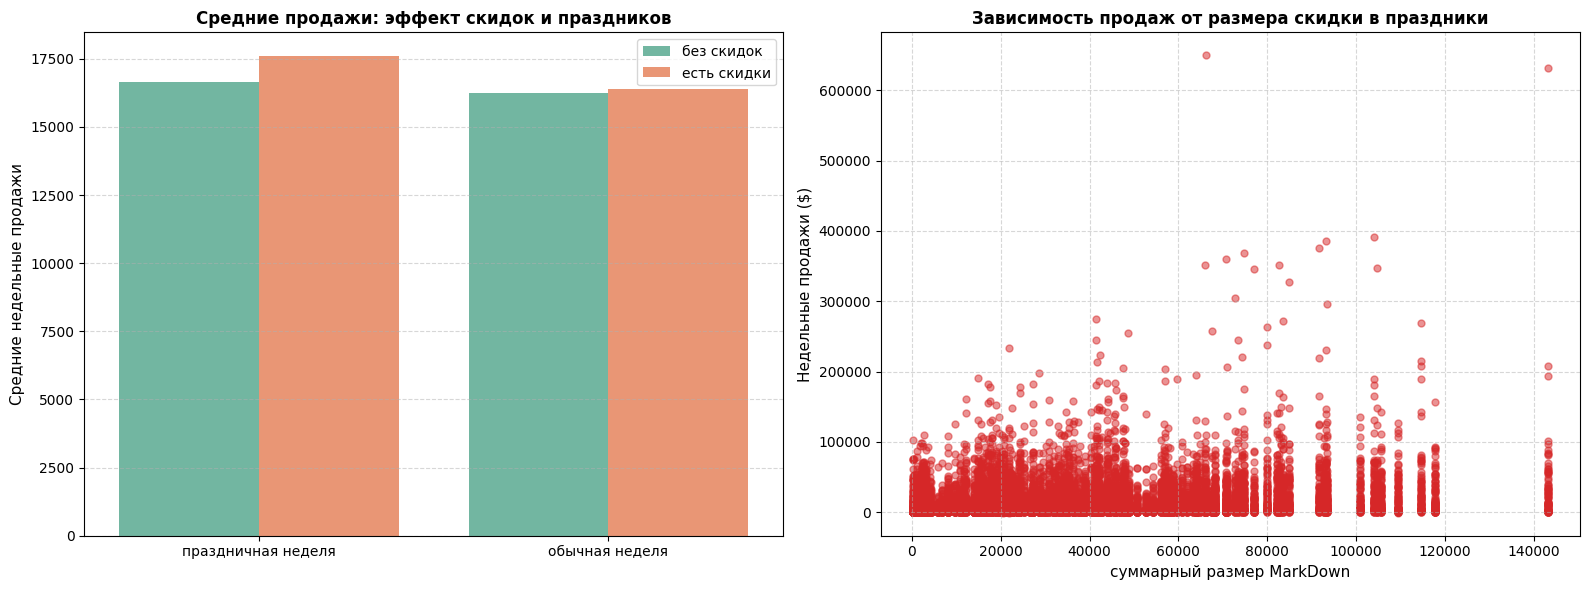

In [359]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# сравнение средних продаж
sns.barplot(
    data=plot_data,
    x='Holiday_Label',
    y='Weekly_Sales',
    hue='Promo_Label',
    palette='Set2',
    ax=axes[0],
    errorbar=None
)
axes[0].set_title('Средние продажи: эффект скидок и праздников', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Средние недельные продажи', fontsize=11)
axes[0].set_xlabel('')
axes[0].legend(title='')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)


# зависимость продаж от размера скидки в праздники
holiday_subset = plot_data[(plot_data['IsHoliday'] == True) & (plot_data['Total_MarkDown'] > 0)]

axes[1].scatter(
    holiday_subset['Total_MarkDown'],
    holiday_subset['Weekly_Sales'],
    alpha=0.5,
    color='#d62728',
    s=25
)
axes[1].set_title('Зависимость продаж от размера скидки в праздники', fontsize=12, fontweight='bold')
axes[1].set_xlabel('суммарный размер MarkDown', fontsize=11)
axes[1].set_ylabel('Недельные продажи ($)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [360]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [361]:
result_2['Date'] = pd.to_datetime(result_2['Date'], errors='coerce')

# IsHoliday к строковому типу для ANOVA
if str(result_2['IsHoliday'].dtype) == 'category':
    result_2['IsHoliday_bool'] = result_2['IsHoliday'].astype(str).str.lower().isin(['true', '1', 'yes'])
else:
    result_2['IsHoliday_bool'] = result_2['IsHoliday'].astype(bool)

result_2['Holiday_Str'] = result_2['IsHoliday_bool'].map({True: 'Holiday', False: 'Normal'})
result_2['Promo_Str'] = result_2['Has_Markdown'].map({True: 'Promo', False: 'No_Promo'})

In [362]:
# Two-Way ANOVA для проверки синергии
# проверяем, есть ли не просто суммарный эффект, а именно мультипликативное взаимодействие (Holiday * Promo)

anova_df = result_2[['Weekly_Sales', 'Holiday_Str', 'Promo_Str']].dropna().copy()

# cемплируем на всякий случай, чтоб не было зависаний
if len(anova_df) > 50000:
    anova_df = anova_df.sample(50000, random_state=42)

model = ols('Weekly_Sales ~ C(Holiday_Str) + C(Promo_Str) + C(Holiday_Str):C(Promo_Str)', data=anova_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)


print(anova_table)

                                   sum_sq       df         F    PR(>F)
C(Holiday_Str)               3.362478e+09      1.0  6.699202  0.009648
C(Promo_Str)                 1.574864e+08      1.0  0.313767  0.575381
C(Holiday_Str):C(Promo_Str)  3.649277e+05      1.0  0.000727  0.978489
Residual                     2.509410e+13  49996.0       NaN       NaN


C(Holiday_Str) - праздник, показывает драйвер продаж

C(Promo_Str) - p-value показывает что фактор скидок не является стат.значимым. Раздавать скидки в случайные неждели не даёт роста продаж

C(Holiday_Str):C(Promo_Str) - скидка в праздник, пи-велью прям совсем близок к 1, не дают супер эффекта....

In [363]:
for store_type in result_2['Division'].unique():
    store_data = result_2[result_2['Division'] == store_type]

    holiday_promo = store_data[(store_data['IsHoliday_bool'] == True) & (store_data['Has_Markdown'] == True)]['Weekly_Sales'].dropna()
    holiday_nopromo = store_data[(store_data['IsHoliday_bool'] == True) & (store_data['Has_Markdown'] == False)]['Weekly_Sales'].dropna()

    if len(holiday_promo) > 0 and len(holiday_nopromo) > 0:
        t_stat, p_val = stats.ttest_ind(holiday_promo, holiday_nopromo, equal_var=False)
        lift = ((holiday_promo.mean() / holiday_nopromo.mean()) - 1) * 100

        print(f"{store_type}")
        print(f"  средние продажи праздник+скидка {holiday_promo.mean():,.0f}")
        print(f"  средние продажи праздник без скидки {holiday_nopromo.mean():,.0f}")
        print(f"  прирост выручки {lift:.1f}%")
        print(f"  p-value {p_val:.4e}")
        print(f"  статистически значим {'да' if p_val < 0.05 else 'нет'}")

div_2
  средние продажи праздник+скидка 15,985
  средние продажи праздник без скидки 14,965
  прирост выручки 6.8%
  p-value 2.9647e-02
  статистически значим да
div_3
  средние продажи праздник+скидка 8,457
  средние продажи праздник без скидки 8,464
  прирост выручки -0.1%
  p-value 9.8464e-01
  статистически значим нет
div_1
  средние продажи праздник+скидка 25,074
  средние продажи праздник без скидки 23,490
  прирост выручки 6.7%
  p-value 1.6128e-02
  статистически значим да


In [364]:
# анализ окупаемости скидок в праздники
holiday_promo_data = result_2[(result_2['IsHoliday_bool'] == True) & (result_2['Has_Markdown'] == True)].copy()
holiday_promo_data = holiday_promo_data[holiday_promo_data['Total_MarkDown'] > 0]

if len(holiday_promo_data) > 0:
    holiday_promo_data['ROI_Markup'] = (holiday_promo_data['Weekly_Sales'] - holiday_promo_data['Total_MarkDown']) / holiday_promo_data['Total_MarkDown']

    print(f"ср.редний ROI скидок в праздники {holiday_promo_data['ROI_Markup'].mean():.2f}")

    if holiday_promo_data['ROI_Markup'].mean() > 0:
        print("скидки окупаются")
    else:
        print("не окупается")

ср.редний ROI скидок в праздники 0.59
скидки окупаются


 каждый $1 скидки приносит 59 центов чистой выручки

# Что сделано

### Загрузка и предварительная обработка данных:
* Импортированы три основных датасета (sales, features, stores), настроены типы данных, форматы дат в datetime.

### Инженерная подготовка признаков:
* Выделены календарные атрибуты, сформирован показатель общего объема уценок/скидок по пяти полям скидок, а также создан бинарный флаг наличия скидки.

### Сегментация по размеру магазинов:
* Добавлено разделение торговых точек на дивизионы 1-2-3 на основе их площади.

### Статистический анализ гипотезы:

* Сформированы четыре подвыборки на основе комбинаций: праздник+скидка, праздник без скидки, обычная неделя+скидка, обычная неделя без скидки.

* Выполнены одновыборочные t-тесты (сравнение средних с нулевой гипотезой), двухвыборочные t-тесты (парные сравнения между группами) и двухфакторный дисперсионный анализ (ANOVA) для проверки эффекта взаимодействия факторов «Праздник» и «Скидка».
* Проверен ROI скидок в праздничные периоды.

### Визуализация результатов:

Построены четыре графика:

* столбчатая диаграмма для сравнения средних недельных продаж в четырёх сценариях (праздник с/без скидок, обычная неделя с/без скидок);
* диаграмма рассеяния для анализа зависимости объёма продаж от абсолютного размера уценок в праздничные дни, дифференцирована по типам магазинов;

### Ключевые результаты
ANOVA выявила статистическую значимость фактора «Праздник» (p = 0.0096), но факторы «Скидка» (p = 0.5753) и особенно их взаимодействие (p = 0.9785) оказались незначимыми.

## Какой вывод в итоге?

Средние продажи на праздничных неделях при наличии скидок выше, чем на праздничных неделях без уценок/скидок.

Но, влияет скорее всего не скидка, а именно наличие праздника


ROI скидок: каждый 1 доллар скидки в праздники приносит 0.59 доллара чистой выручки — т.е. скидки не окупаются....




1. Пересмотреть бюджет на скидки. Праздники и так продают хорошо.
2. Изучить, что покупают в праздники

3. Переместить скидочный бюджет на обычные дни
Если скидки вообще работают, их эффективнее использовать в январе, августе для поддержки продаж.

4. Тестировать скидки по отделам и категориям

5. Сосредоточиться на логистике и ассортименте на праздники


И мем 🙂




![данные мои данные...](https://i.pinimg.com/736x/0b/40/34/0b403449858386ad317bbaaff58a1d90.jpg)